# The quantum-computing basket — next big thing, or pure hype? ⚛️
### A basket that returned +59%/yr and *still* lost to the index — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Next_big_thing%3F: Hype--cycle](https://img.shields.io/badge/Next_big_thing%3F-Hype--cycle-8b949e?style=flat-square)

There's a trade everyone's heard: forget the boring index, **buy the quantum stocks** — IONQ, Rigetti, D-Wave, Quantum Computing Inc. — and ride the next computing revolution. And the headline is true: over the last five years that four-stock basket returned about **+59% a year**, while the S&P 500 did **+14%**. Four times the market. Free money, right?

Not quite. That +59% came with a **−84% crash** along the way and a ride so wild that, *per unit of risk*, the basket actually did **worse than the index** — and worse than a boring quantum ETF you could have bought on day one. This notebook is about the gap between *a real technology* and *a good investment* — and why "next big thing" almost never means "buy the basket."

> 📓 **Plain-language layer.** Want the Sharpe ratios, the HAC *t*-stats and the null control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** These four are the quantum names that **survived** to a listing (most arrived via SPAC mergers; many quantum SPACs vanished). Keeping only the survivors flatters the basket — we call that out throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from quantum_computing_basket import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RETS, BENCH = data.load_real(allow_survivorship=True)
    RACE = st.race(RETS, BENCH, data.BASKET, cost_bps=10.0, allow_survivorship=True)
else:
    RETS = BENCH = RACE = None
print("real quantum-panel cache present:", HAVE_REAL,
      "| months:", (0 if RETS is None else len(RETS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2021-05', 'end': '2026-05', 'months': 61, 'years': 5.1, 'fingerprint': 'd955f566bc4b', 'basket': (59.1, 0.75, 160, -84.3), 'basket_net': (58.9, 0.74), 'etf': (27.9, 1.06, 27, -34.5), 'spy': (13.9, 0.91, 16, -23.9), 'qqq': (17.3, 0.88, 21, -32.6), 't_spy': (104.6, 1.23, 61), 't_qqq': (100.8, 1.19, 61), 't_etf': (90.8, 1.12, 61), 'names': {'IONQ': (45.3, 117, -86, 76.8, 1.4), 'QBTS': (24.4, 174, -95, 105.2, 1.27), 'RGTI': (20.4, 218, -96, 119.4, 1.11), 'QUBT': (14.1, 260, -95, 117.1, 0.9)}, 'syn': [(0.0, -10.6, 0.23, 4.7, 0.18), (1.0, 256.5, 2.05, 146.9, 5.71)]}


real quantum-panel cache present: True | months: 61


## The answer first

| Question | Answer |
|---|---|
| Did the quantum basket beat the market? | **By a mile — +59%/yr vs +14%/yr.** That's the hook. |
| So it's a great investment? | **No.** It got there at **160% volatility** with an **-84% crash**. Per unit of risk (its *Sharpe*) it scored **0.75** — *below* the S&P 500's **0.91**. |
| Is the outperformance even real? | **Can't tell.** The gap is so noisy that statistically it's **indistinguishable from luck** (a proper *t*-test scores **1.23**, far below the ~2 you'd need). |
| Was there a sane way to play quantum? | **Yes — the diversified QTUM ETF** (+28%/yr, Sharpe **1.06**), which beat *both* the basket and the index on risk-adjusted terms — and you could have bought it from day one. |

> The technology is real. The basket is a **high-variance lottery** wearing a thesis. A +59%/yr number you can't hold through an −84% drawdown isn't an edge.

## 1 · The claim

> *"Quantum computing is the next AI — a once-in-a-generation technology. Don't stock-pick; just **hold the pure-plays** — IONQ, RGTI, QBTS, QUBT — equal-weight and ride the whole wave."*

It's a seductive pitch, and it's been everywhere since Google's *Willow* chip headline in late 2024 sent the names vertical. The logic feels airtight: a transformative technology **must** mean its listed champions go up. We'll rebuild that exact basket and look at what holding it actually felt like — not just where it ended up.

## 2 · So what?

Two very different things hide inside "the basket went up 59% a year," and only one is an investment. (1) *Did it produce a big number?* Yes. (2) *Were you **paid** for the risk you took to get it — could you actually have held it?* That's the whole game. A return you only capture if you sit through an **−84% drawdown** without flinching isn't a strategy a human (or a fund) can run. And if a *diversified* version of the same theme gives you a **better ride for less risk**, the concentrated lottery basket isn't even the smart way to be bullish on quantum.

## 3 · How would we even know?

We rebuild the basket honestly: the four pure-plays, equal-weight, rebalanced monthly, over the **5 years** (2021-05 → 2026-05, 61 months) all four have traded. Then we line it up against three yardsticks:

1. **The market (SPY)** and **the tech tape (QQQ)** — what you'd have earned the boring way.
2. **The diversified quantum ETF (QTUM)** — the sane way to bet on the theme.
3. **The risk** — not just the return, but the *volatility* and the *worst drawdown*, because that's what decides whether a number is holdable.

And we ask the honest statistician's question: with only five years and a couple of violent up-months, **is the gap big enough to be real, or could a coin have done it?**

## 4 · The teardown — let's actually look

**First, the growth-of-$1 chart.** Watch where the basket goes — and where it *was* in between.

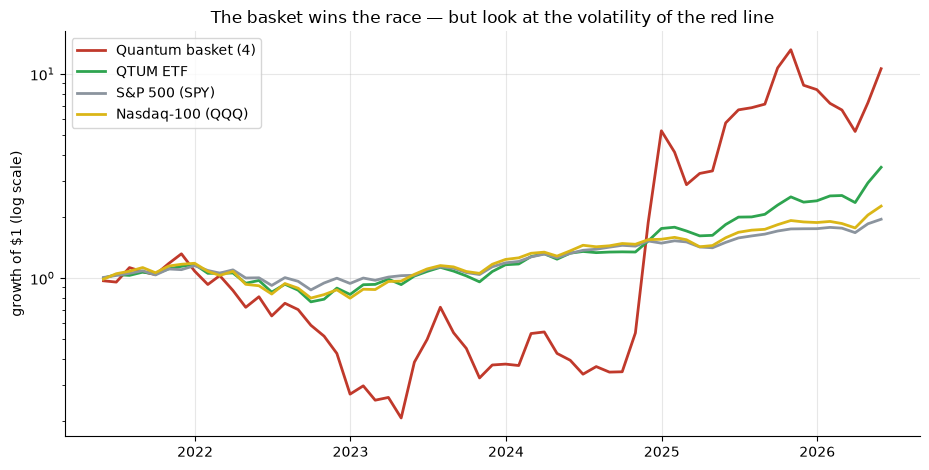

basket end multiple: 10.6 x


In [2]:
if HAVE_REAL:
    legs = {'Quantum basket (4)': RACE['basket'], 'QTUM ETF': RACE['etf'],
            'S&P 500 (SPY)': RACE['spy'], 'Nasdaq-100 (QQQ)': RACE['qqq']}
    cols = {'Quantum basket (4)': RED, 'QTUM ETF': GREEN, 'S&P 500 (SPY)': GREY, 'Nasdaq-100 (QQQ)': AMBER}
    fig, ax = plt.subplots(figsize=(9.4, 4.8))
    for name, r in legs.items():
        eq = (1+r.dropna()).cumprod()
        ax.plot(eq.index, eq.values, lw=2, color=cols[name], label=name)
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log scale)')
    ax.set_title('The basket wins the race — but look at the volatility of the red line')
    ax.legend(); plt.tight_layout(); plt.show()
    print('basket end multiple:', round(float((1+RACE['basket'].dropna()).prod()),1), 'x')
else:
    print('no cache — see docs/results.md: basket +59.1%/yr vs SPY +13.9%/yr over 61 months')

The red basket line ends *highest* — that's the **+59%/yr** headline. But notice how violently it swings. The chart hides the worst part: the *path*. Let's put the risk on screen.

**The return you see vs the risk you don't.** Same four legs — but now CAGR next to the **worst drawdown** each one put you through.

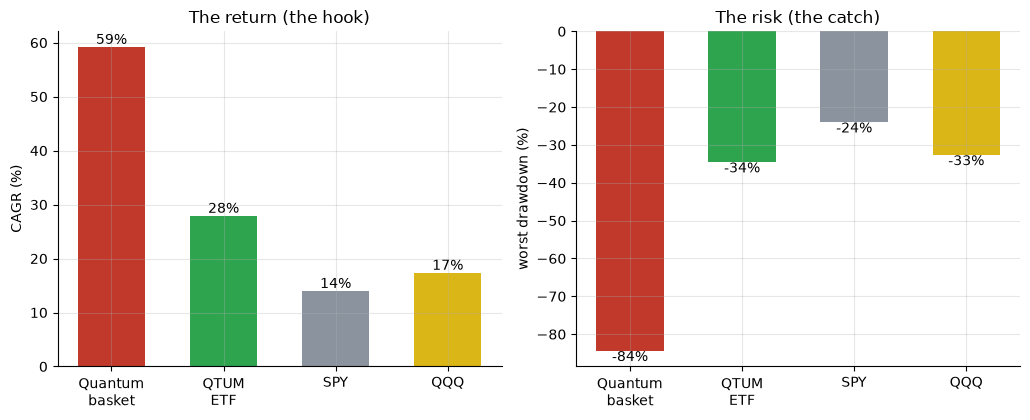

basket worst drawdown: -84%  vs SPY: -24%


In [3]:
labels = ['Quantum\nbasket', 'QTUM\nETF', 'SPY', 'QQQ']
if HAVE_REAL:
    s = RACE['summ']
    cagr = [s['basket']['cagr'], s['etf']['cagr'], s['spy']['cagr'], s['qqq']['cagr']]
    dd = [s['basket']['max_dd'], s['etf']['max_dd'], s['spy']['max_dd'], s['qqq']['max_dd']]
else:
    cagr = [R['basket'][0]/100, R['etf'][0]/100, R['spy'][0]/100, R['qqq'][0]/100]
    dd = [R['basket'][3]/100, R['etf'][3]/100, R['spy'][3]/100, R['qqq'][3]/100]
x = np.arange(len(labels))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.3))
a1.bar(x, [c*100 for c in cagr], color=[RED, GREEN, GREY, AMBER], width=.6)
a1.set_xticks(x); a1.set_xticklabels(labels); a1.set_ylabel('CAGR (%)')
a1.set_title('The return (the hook)')
for i,c in enumerate(cagr): a1.annotate(f'{c*100:.0f}%',(i,c*100),ha='center',va='bottom')
a2.bar(x, [d*100 for d in dd], color=[RED, GREEN, GREY, AMBER], width=.6)
a2.set_xticks(x); a2.set_xticklabels(labels); a2.set_ylabel('worst drawdown (%)')
a2.set_title('The risk (the catch)')
for i,d in enumerate(dd): a2.annotate(f'{d*100:.0f}%',(i,d*100),ha='center',va='top')
plt.tight_layout(); plt.show()
print('basket worst drawdown:', f'{dd[0]*100:.0f}%', ' vs SPY:', f'{dd[3-1]*100:.0f}%')

There's the catch. To earn the basket's **+59%/yr** you had to survive an **-84%** drawdown — your $100 became roughly $16 at the bottom. The index's worst was 24%. Almost nobody holds through an 84% loss; they sell at the bottom and the headline return is one they never actually got.

**Reward per unit of risk — the Sharpe ratio.** This is the single number that asks "was the wild ride *worth it*?" Higher is better; the index sets the bar.

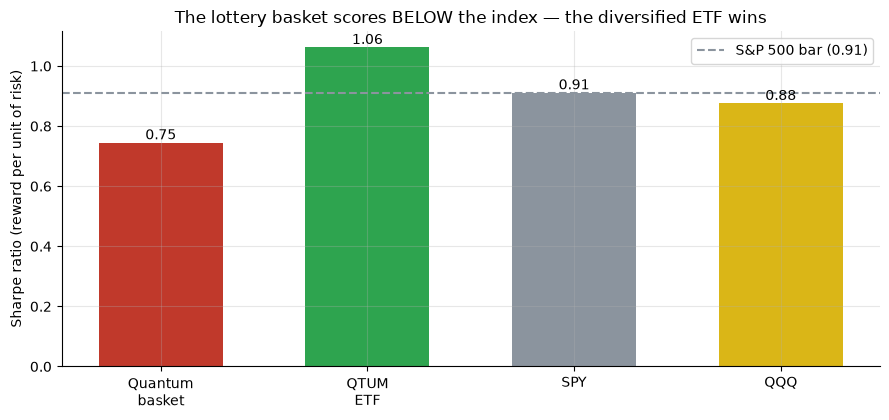

basket Sharpe 0.75 < SPY 0.91 < QTUM ETF 1.06


In [4]:
if HAVE_REAL:
    s = RACE['summ']
    sh = [s['basket']['sharpe'], s['etf']['sharpe'], s['spy']['sharpe'], s['qqq']['sharpe']]
else:
    sh = [R['basket'][1], R['etf'][1], R['spy'][1], R['qqq'][1]]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
bars = ax.bar(x, sh, color=[RED, GREEN, GREY, AMBER], width=.6)
ax.axhline(sh[2], ls='--', c=GREY, label=f'S&P 500 bar ({sh[2]:.2f})')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('Sharpe ratio (reward per unit of risk)')
ax.set_title('The lottery basket scores BELOW the index — the diversified ETF wins')
for i,v in enumerate(sh): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('basket Sharpe', f'{sh[0]:.2f}', '< SPY', f'{sh[2]:.2f}', '< QTUM ETF', f'{sh[1]:.2f}')

This is the whole study in one chart. The flashy basket scores **0.75** — *below* the S&P 500's **0.91**. The boring **diversified QTUM ETF** wins outright at **1.06**. Per unit of white-knuckle risk, the concentrated quantum bet paid you **less** than doing nothing — and a sane quantum ETF paid you more than either.

## 5 · The verdict

- **Signal — Weak.** The basket really beat the market (+59%/yr) — but the gap is so noisy it's statistically **indistinguishable from luck**, and per unit of risk it scored *below* the index. Real raw return, no real edge.
- **Tradability — Mirage.** A **160%-vol**, **-84%-drawdown** sleeve isn't something you can actually hold or size. Risk-adjusted it loses to both SPY and the diversified ETF.
- **Next big thing? — Hype-cycle.** A real technology with no profits yet, and a stock cohort that's a **high-variance lottery dressed as a thesis**. The sane way to be bullish on quantum was the boring ETF all along. ([Study 393](../393-ai-datacenter-basket/) is the same trick in an AI costume.)

## 6 · Could you actually trade it? — one stock or four?

Maybe the basket is really carried by one moon-shot. Here's each name's own return and its own worst drawdown. The punchline is that *every* one is a casino chip.

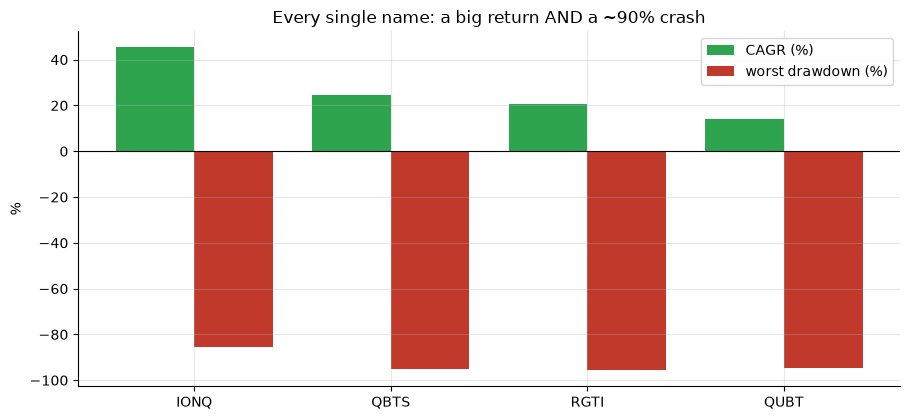

worst single-name drawdowns: {'IONQ': '-86%', 'QBTS': '-95%', 'RGTI': '-96%', 'QUBT': '-95%'}


In [5]:
names = list(R['names'].keys())
if HAVE_REAL:
    cg = [RACE['single_names'][n]['cagr']*100 for n in names]
    dd = [RACE['single_names'][n]['max_dd']*100 for n in names]
else:
    cg = [R['names'][n][0] for n in names]; dd = [R['names'][n][2] for n in names]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cg, .4, color=GREEN, label='CAGR (%)')
ax.bar(x+.2, dd, .4, color=RED, label='worst drawdown (%)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel('%')
ax.set_title('Every single name: a big return AND a ~90% crash')
ax.legend(); plt.tight_layout(); plt.show()
print('worst single-name drawdowns:', {n: f'{d:.0f}%' for n,d in zip(names,dd)})

Every one of the four drew down **96%-class** — that is, they each lost roughly **nine-tenths of their value** at some point. A basket of four lottery tickets is still a basket of lottery tickets; diversifying across them softens nothing because they all crash together on the same risk-off days. Costs, by the way, are a non-issue (a few bps on a monthly hold) — **risk**, not friction, is what makes this untradeable.

## 7 · Going further 🚪

- **The sibling.** [Study 393 — AI-Datacenter-Basket](../393-ai-datacenter-basket/) is the same "buy the theme" trade for AI infrastructure — there the spread is real but *hand-picked in hindsight*; here it's *risk that isn't paid for*. Two ways the same thematic hook misleads.
- **The disruptive-tech fund.** [Study 334 — ARK-Innovation](../334-ark-innovation/) — does riding "innovation" pay you risk-adjusted? Same family of high-vol theme bets.
- **Build your own.** Swap the four pure-plays for the QTUM ETF holdings, or add the mega-cap quantum efforts (GOOGL, IBM, MSFT), and re-run — the more diversified you get, the more the lottery tail shrinks and the Sharpe climbs.

*Think the concentrated basket beats the ETF on risk-adjusted terms? Show its Sharpe clearing the index's **and** its spread clearing t = 2 — then we'll talk.*